In [16]:
using Plots
using LinearAlgebra
using Random
using Statistics

In [49]:
# Physical parameters
c = 3e8
f = 433e6
λ = c / f

# Array parameters
N = 5
d = λ / 2
x = ((0:N-1) .- (N-1)/2) .* d

# True direction of arrival
theta_true_deg = 75
theta_true = deg2rad(theta_true_deg)

# Signal received by each antenna
received = exp.(im .* (2 * π / λ) .* x .* cos(theta_true))

# Show received phases
received_phase_deg = rad2deg.(angle.(received))

println("True AoA = ", theta_true_deg, " degrees")
println("Received phases = ", received_phase_deg)

True AoA = 75 degrees
Received phases = [-93.17485623690747, -46.587428118453744, 0.0, 46.587428118453744, 93.17485623690747]


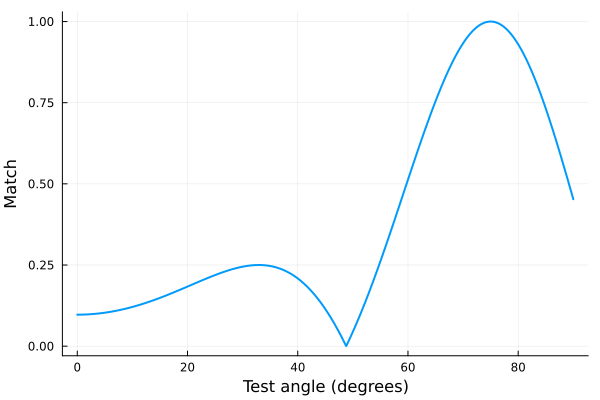

In [50]:
# Angles that the receiver will test
theta_test_deg = 0:0.1:90
theta_test = deg2rad.(theta_test_deg)

score = zeros(length(theta_test))

for k = 1:length(theta_test)

    # Expected phase pattern for this test angle
    a = exp.(im .* (2 * π / λ) .* x .* cos(theta_test[k]))

    # Compare expected phases with measured phases
    score[k] = abs(sum(conj.(a) .* received))
end

score = score ./ maximum(score)

plot(theta_test_deg, score,
    xlabel = "Test angle (degrees)",
    ylabel = "Match",
    label = false,
    linewidth = 2)

In [51]:
best_index = argmax(score)
theta_est_deg = theta_test_deg[best_index]

println("Estimated AoA = ", theta_est_deg, " degrees")

Estimated AoA = 75.0 degrees


# Realistic Receive Simulation

The ideal simulations above assumed perfect antenna signals. This section gradually introduces practical receiver effects while keeping the true direction of arrival fixed.

The signal is first generated in its clean form. Noise, gain mismatch and phase mismatch are then added progressively. Direction-of-arrival processing is performed only after the received signal has been corrupted, followed by calibration and comparison of the results.

In [52]:
# IQ signal settings
fs = 1e6
f0 = 50e3
Ns = 1000

t = (0:Ns-1) / fs

# Baseband IQ signal
s = exp.(im .* 2 .* π .* f0 .* t)

# Phase pattern across the 5 antennas
a_true = exp.(im .* (2 * π / λ) .* x .* cos(theta_true))

# Clean received IQ data
X_clean = zeros(ComplexF64, N, Ns)

for m = 1:N
    X_clean[m, :] = a_true[m] .* s
end

println("Clean IQ data size = ", size(X_clean))

Clean IQ data size = (5, 1000)


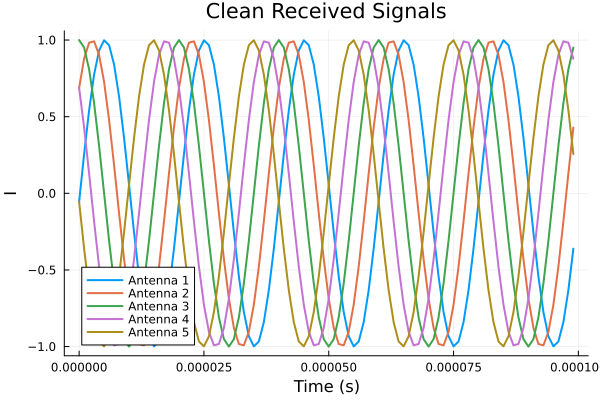

In [53]:
# Plot the first 100 samples from all 5 antennas
plot(t[1:100], real.(X_clean[:, 1:100])',
    xlabel = "Time (s)",
    ylabel = "I",
    label = ["Antenna 1" "Antenna 2" "Antenna 3" "Antenna 4" "Antenna 5"],
    linewidth = 2,
    title = "Clean Received Signals")

In [54]:
# Add noise
SNR_dB = 10
noise_power = 10^(-SNR_dB / 10)

noise = sqrt(noise_power / 2) .* (
    randn(N, Ns) .+ im .* randn(N, Ns)
)

X_noise = X_clean + noise

5×1000 Matrix{ComplexF64}:
 -0.136689-1.08353im    0.0205308-1.10174im   …  -0.66006-1.1186im
  0.581439-0.871076im     1.30069-0.364193im     0.515399-0.763923im
   1.01785+0.0379736im    1.25784+0.323772im     0.977445-0.34818im
  0.667228+0.706047im     0.64026+1.04008im      0.810855-0.00587714im
  0.387578+1.15885im    -0.368299+0.475672im     0.592952+1.07693im

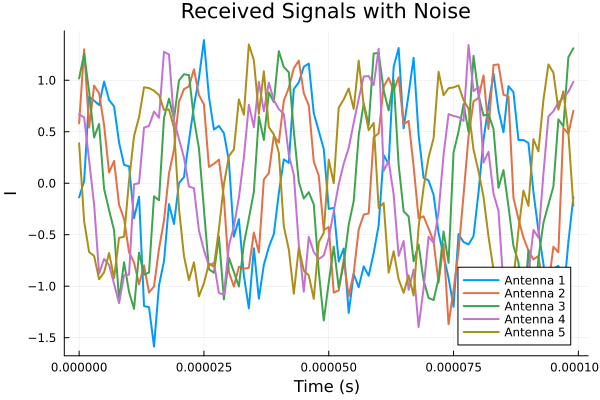

In [55]:
plot(t[1:100], real.(X_noise[:, 1:100])',
    xlabel = "Time (s)",
    ylabel = "I",
    label = ["Antenna 1" "Antenna 2" "Antenna 3" "Antenna 4" "Antenna 5"],
    linewidth = 2,
    title = "Received Signals with Noise")

In [56]:
# Gain mismatch between antenna paths
gain_error = [0.85, 1.10, 1.00, 0.90, 1.15]

# Apply gain mismatch to the noisy signal
X_gain = X_noise .* reshape(gain_error, N, 1)

5×1000 Matrix{ComplexF64}:
 -0.116185-0.920998im   0.0174512-0.936477im  …  -0.561051-0.95081im
  0.639583-0.958184im     1.43076-0.400612im      0.566938-0.840315im
   1.01785+0.0379736im    1.25784+0.323772im      0.977445-0.34818im
  0.600505+0.635442im    0.576234+0.936072im      0.729769-0.00528942im
  0.445715+1.33268im    -0.423544+0.547023im      0.681895+1.23847im

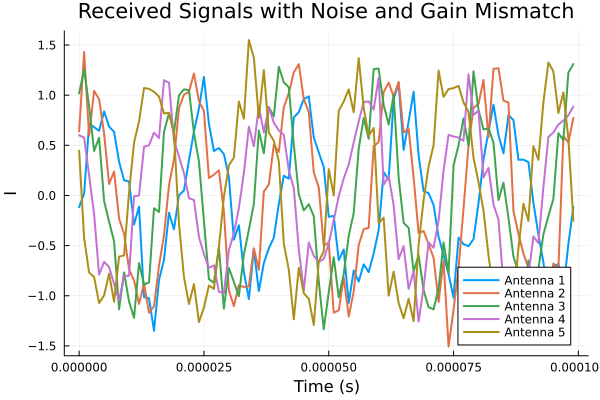

In [57]:
plot(t[1:100], real.(X_gain[:, 1:100])',
    xlabel = "Time (s)",
    ylabel = "I",
    label = ["Antenna 1" "Antenna 2" "Antenna 3" "Antenna 4" "Antenna 5"],
    linewidth = 2,
    title = "Received Signals with Noise and Gain Mismatch")

In [58]:
# Fixed phase mismatch between antenna paths
phase_error_deg = [-8, 4, 0, -5, 7]
phase_error = deg2rad.(phase_error_deg)

# Apply phase mismatch
X_corrupted = X_gain .* reshape(exp.(im .* phase_error), N, 1)

5×1000 Matrix{ComplexF64}:
 -0.243233-0.895865im   -0.113051-0.929792im  …  -0.687918-0.863473im
  0.704865-0.911235im     1.45522-0.299831im      0.624175-0.798721im
   1.01785+0.0379736im    1.25784+0.323772im      0.977445-0.34818im
  0.653602+0.580687im    0.655626+0.882288im      0.726531-0.0688729im
   0.27998+1.37707im    -0.487053+0.491328im      0.525881+1.31234im

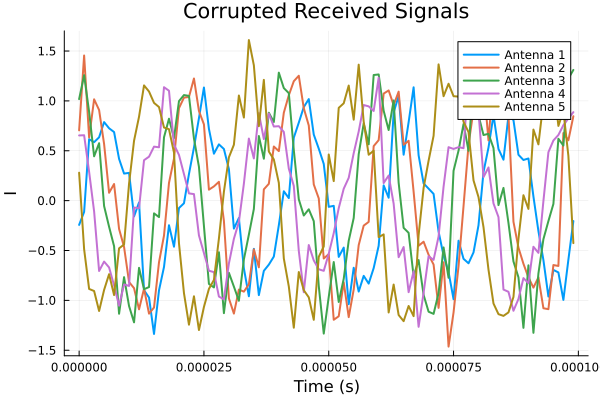

In [59]:
plot(t[1:100], real.(X_corrupted[:, 1:100])',
    xlabel = "Time (s)",
    ylabel = "I",
    label = ["Antenna 1" "Antenna 2" "Antenna 3" "Antenna 4" "Antenna 5"],
    linewidth = 2,
    title = "Corrupted Received Signals")

# Direction-of-Arrival Processing

The received signal has now been corrupted by noise, gain mismatch and phase mismatch.

In this section, the direction-of-arrival algorithm processes the corrupted antenna signals and estimates the incoming signal direction.

In [60]:
# Angles to test
theta_test_deg = 0:0.1:90
theta_test = deg2rad.(theta_test_deg)

# Beamformer output power
power_corrupted = zeros(length(theta_test))

for k = 1:length(theta_test)
    a = exp.(im .* (2 * π / λ) .* x .* cos(theta_test[k]))
    y = vec(a' * X_corrupted)

    power_corrupted[k] = mean(abs2.(y))
end

# Normalise
power_corrupted = power_corrupted ./ maximum(power_corrupted)

# Estimated AoA
theta_est = theta_test_deg[argmax(power_corrupted)]

println("True AoA      = ", theta_true_deg, " degrees")
println("Estimated AoA = ", theta_est, " degrees")

True AoA      = 75 degrees
Estimated AoA = 74.3 degrees


# Calibration

The corrupted received signals contain systematic gain and phase differences between the antenna paths.

Assuming these hardware offsets have been measured during a calibration procedure, they can be compensated before direction-of-arrival estimation is performed again.

In [61]:
# Correct gain mismatch
X_calibrated = X_corrupted ./ reshape(gain_error, N, 1)

# Correct phase mismatch
X_calibrated = X_calibrated .* reshape(exp.(-im .* phase_error), N, 1);

In [62]:
power_calibrated = zeros(length(theta_test))

for k = 1:length(theta_test)
    a = exp.(im .* (2 * π / λ) .* x .* cos(theta_test[k]))
    y = vec(a' * X_calibrated)

    power_calibrated[k] = mean(abs2.(y))
end

power_calibrated = power_calibrated ./ maximum(power_calibrated)

theta_calibrated = theta_test_deg[argmax(power_calibrated)]

println("Before calibration = ", theta_est, " degrees")
println("After calibration  = ", theta_calibrated, " degrees")

Before calibration = 74.3 degrees
After calibration  = 74.9 degrees


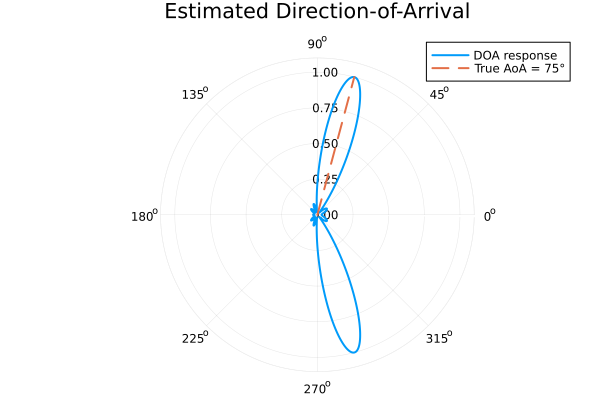

In [63]:
# Full angular scan for polar beam pattern
theta_plot_deg = -180:0.1:180
theta_plot = deg2rad.(theta_plot_deg)

beam = zeros(length(theta_plot))

for k = 1:length(theta_plot)
    a = exp.(im .* (2 * π / λ) .* x .* cos(theta_plot[k]))
    y = vec(a' * X_calibrated)
    beam[k] = mean(abs2.(y))
end

beam = beam ./ maximum(beam)

# Polar beam pattern
plot(theta_plot, beam,
    proj = :polar,
    label = "DOA response",
    linewidth = 2,
    title = "Estimated Direction-of-Arrival")

# True direction
plot!([deg2rad(theta_true_deg), deg2rad(theta_true_deg)],
      [0, 1],
      linewidth = 2,
      linestyle = :dash,
      label = "True AoA = $(theta_true_deg)°")